<a href="https://colab.research.google.com/github/Nevil-Roy/Apartment-Watcher/blob/main/fcc_MAGIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

### DataSet
UCI Machine learning repo
MAGIC Gamma Telescope

In [5]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConcl", "fAsyme","fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()

,fLength,fWidth,fSize,fConc,fConcl,fAsyme,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [6]:
df["class"].unique()

array(['g', 'h'], dtype=object)

In [7]:
df["class"] = (df["class"] == "g").astype(int)

In [8]:
df.head()

,fLength,fWidth,fSize,fConc,fConcl,fAsyme,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [9]:
df.tail()

,fLength,fWidth,fSize,fConc,fConcl,fAsyme,fM3Long,fM3Trans,fAlpha,fDist,class
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0
19019,187.1814,53.0014,3.2093,0.2876,0.1539,-167.3125,-168.4558,31.4755,52.7310,272.3174,0


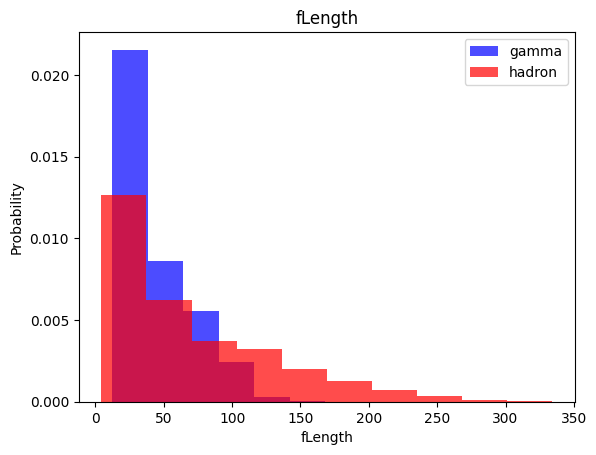

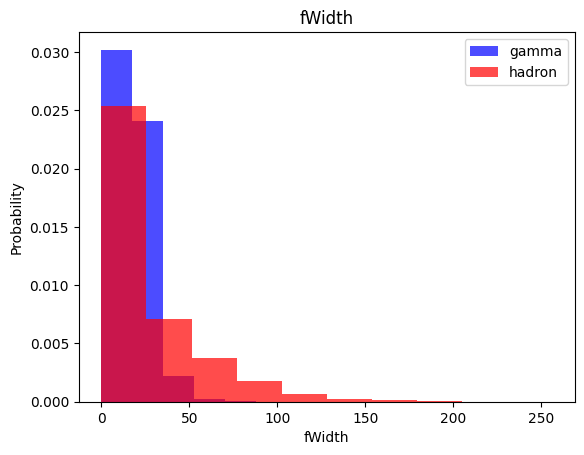

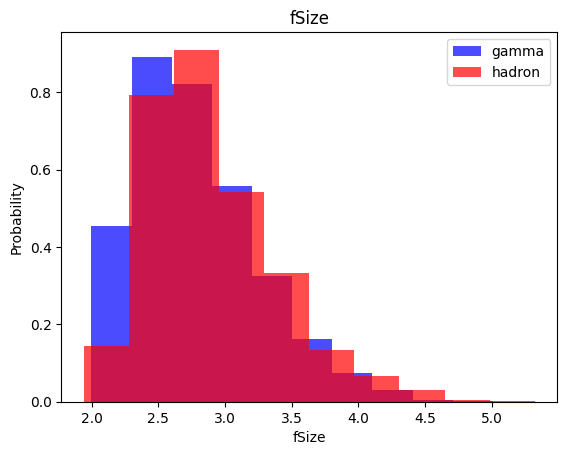

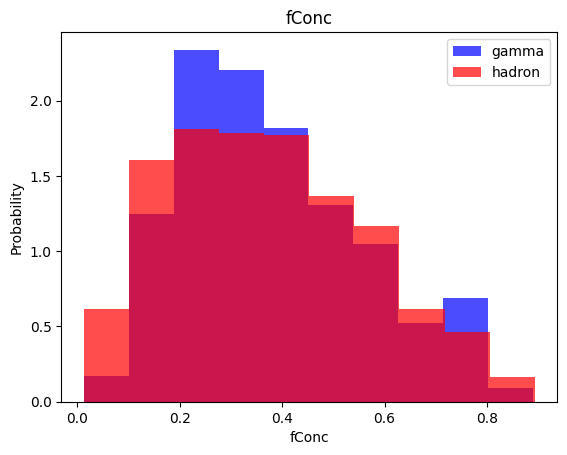

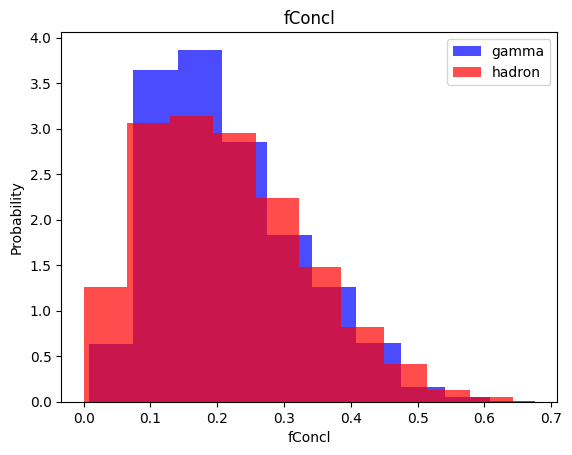

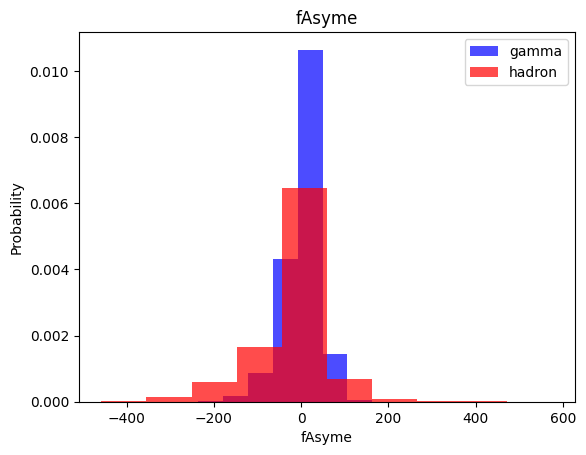

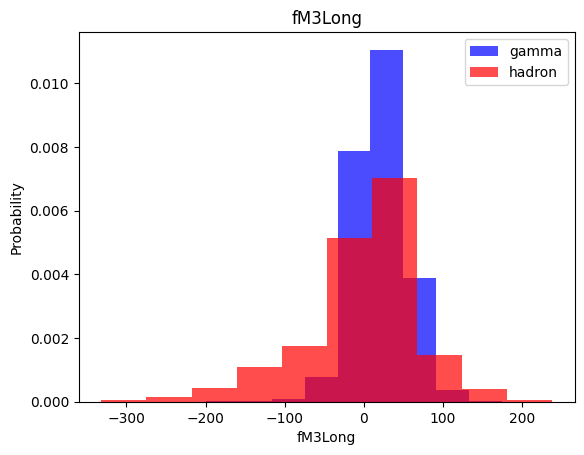

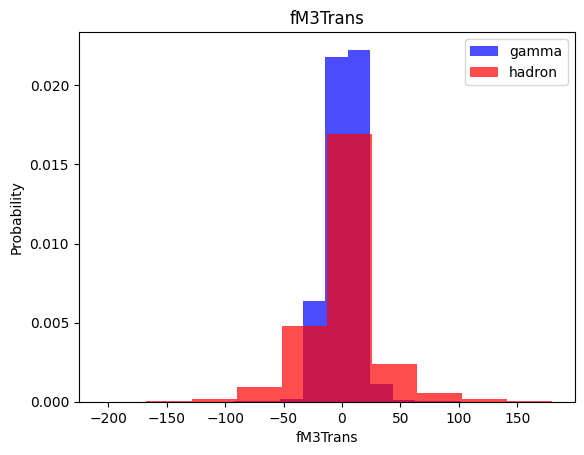

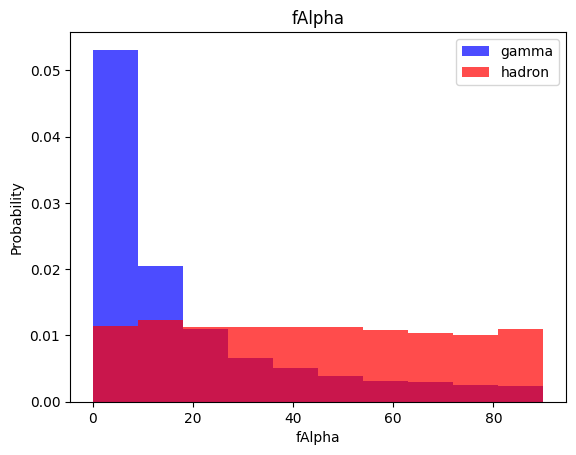

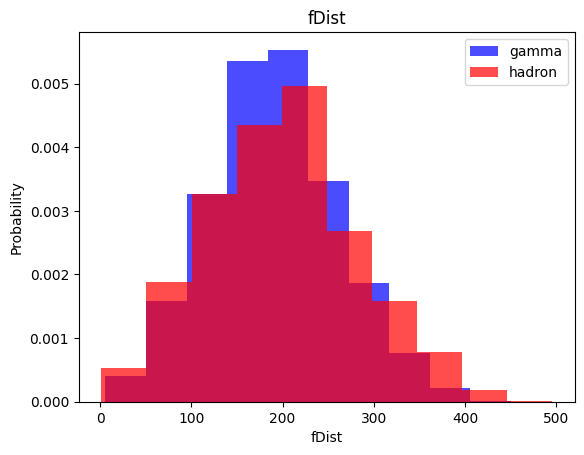

In [10]:
for label in cols[:-1]:
  plt.hist(df[df["class"] == 1][label], color = 'blue', label= 'gamma', alpha=0.7, density=True)
  plt.hist(df[df["class"] == 0][label], color = 'red', label= 'hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()


# Train, validation, test datasets

---



In [11]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


The values of each colums in the dataset varies from from negatvie and small numbers to positive and large numbers. The scale is way off. we have to scale it to the mean and the standard deviation of that specific column
--------------------------
In test case the number of gamma and other is not the same. Thats why, we have to oversample over training data set so that these mataches better

In [12]:
print(len(train[train["class"] == 1])) # gammas
print(len(train[train["class"] == 0])) # others

7411
4001


In [13]:
def scale_dataset(dataframe, oversample = False):
  X = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  X = scaler.fit_transform(X) # learn the mean/std and scale the data using them

  # if less class, keep sampling from there to increase the size of the dataset
  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X,y)


  # stack horizondally side by side. X here is 2D and y is vector
  data = np.hstack((X, np.reshape(y, (-1, 1)))) # here -1 is same as len(y)

  return data, X, y


In [14]:
train_scaled, X_train, y_train = scale_dataset(train, oversample = True)
valid_scaled, X_valid, y_valid = scale_dataset(valid, oversample = False)
test_scaled, X_test, y_test = scale_dataset(test, oversample = False)

# Update the original train, valid, test variables to hold the scaled numpy arrays
train = train_scaled
valid = valid_scaled
test = test_scaled

In [15]:
len(y_train)
sum(y_train == 1)
sum(y_train == 0)

np.int64(7411)

# K - nearest neighbors {kNN}

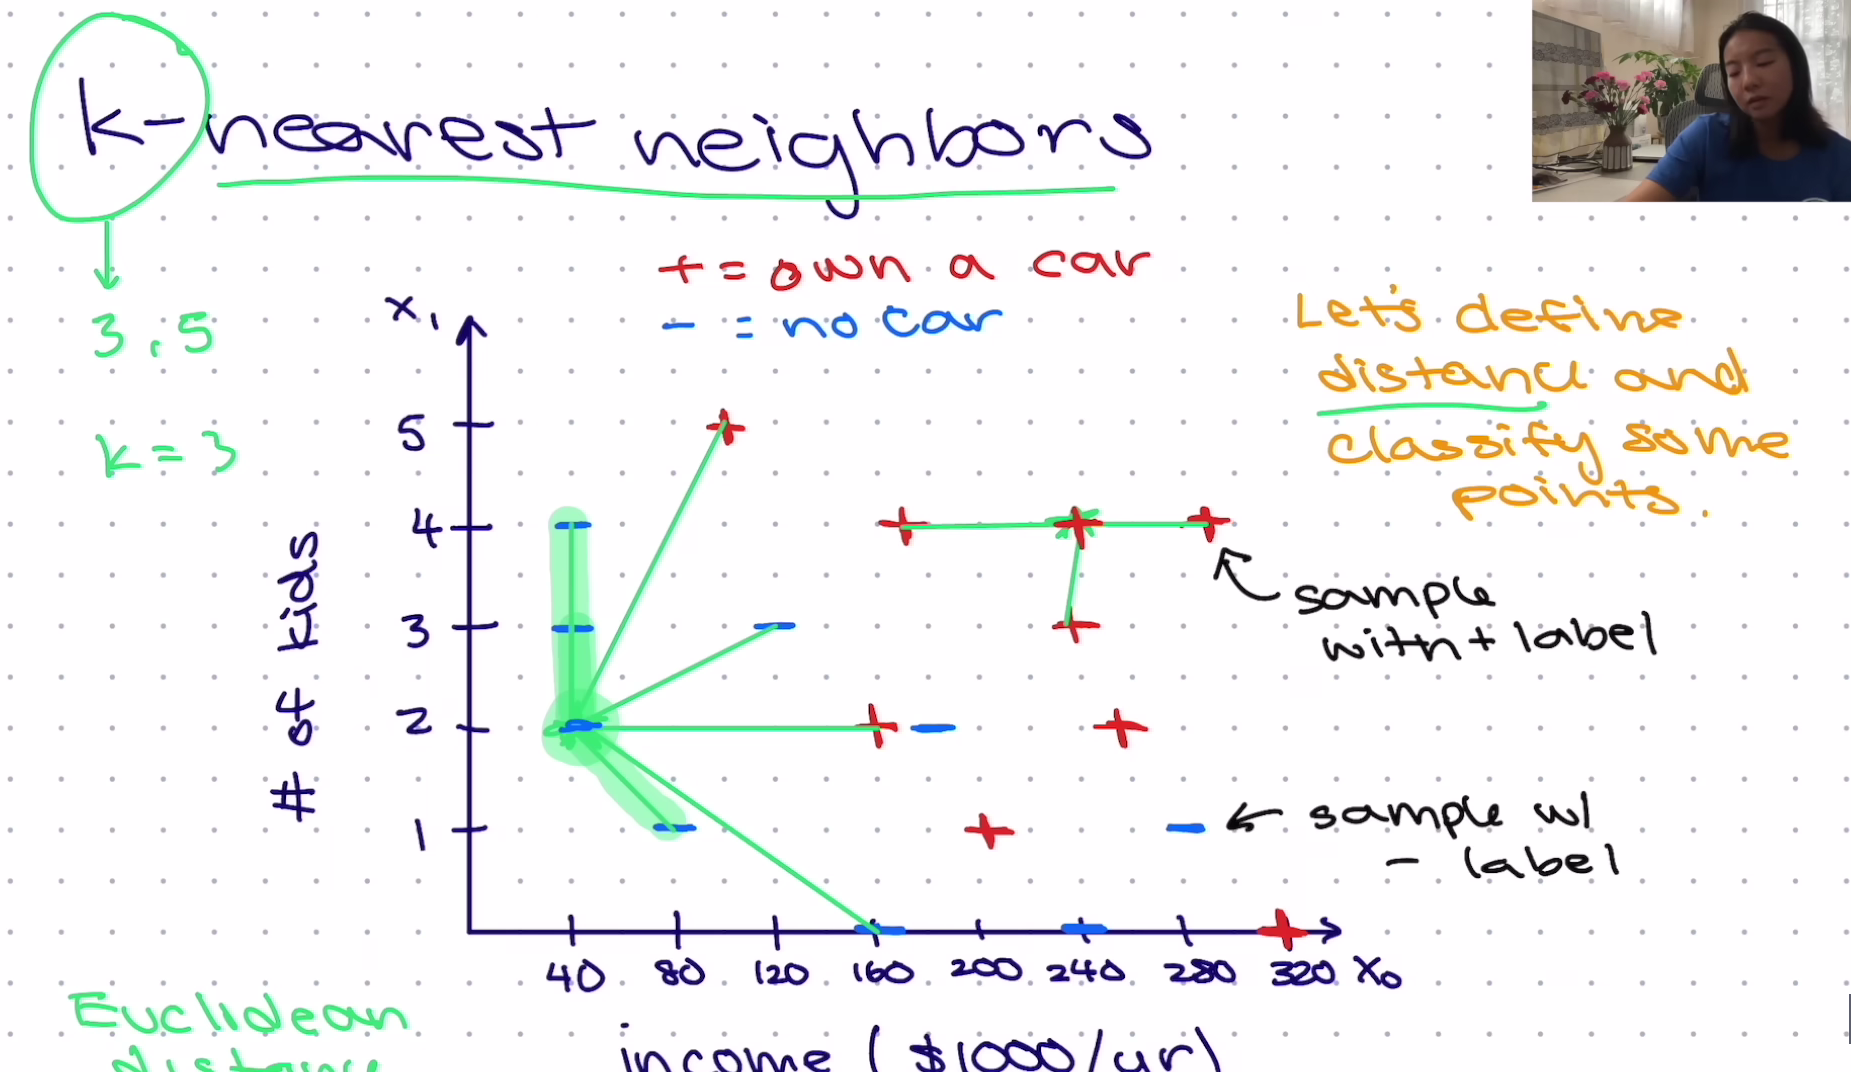

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [25]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [26]:
y_predict = knn_model.predict(X_test)

In [27]:
y_predict

array([1, 1, 1, ..., 1, 0, 1])

In [28]:
y_test

array([1, 1, 1, ..., 1, 0, 1])

In [29]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74      1351
           1       0.85      0.87      0.86      2453

    accuracy                           0.82      3804
   macro avg       0.81      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



# Naive Bayes

Naive Bayes = look at the features → calculate probabilities → choose the most likely class.

Words in email
      ↓
Calculate probabilities
      ↓
Spam:     85%
Not Spam: 15%
      ↓
Prediction: SPAM

In [30]:
from sklearn.naive_bayes import GaussianNB

In [32]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [33]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.70      0.41      0.51      1351
           1       0.73      0.90      0.81      2453

    accuracy                           0.73      3804
   macro avg       0.72      0.65      0.66      3804
weighted avg       0.72      0.73      0.70      3804



# Logistic Regression

Based on the features, what is the probability that this belongs to class 1?

Logistic Regression

Input features
      ↓
   Calculate
   probability
      ↓
   0 to 1
      ↓
  0.5 threshold
      ↓
Class 0 or Class 1

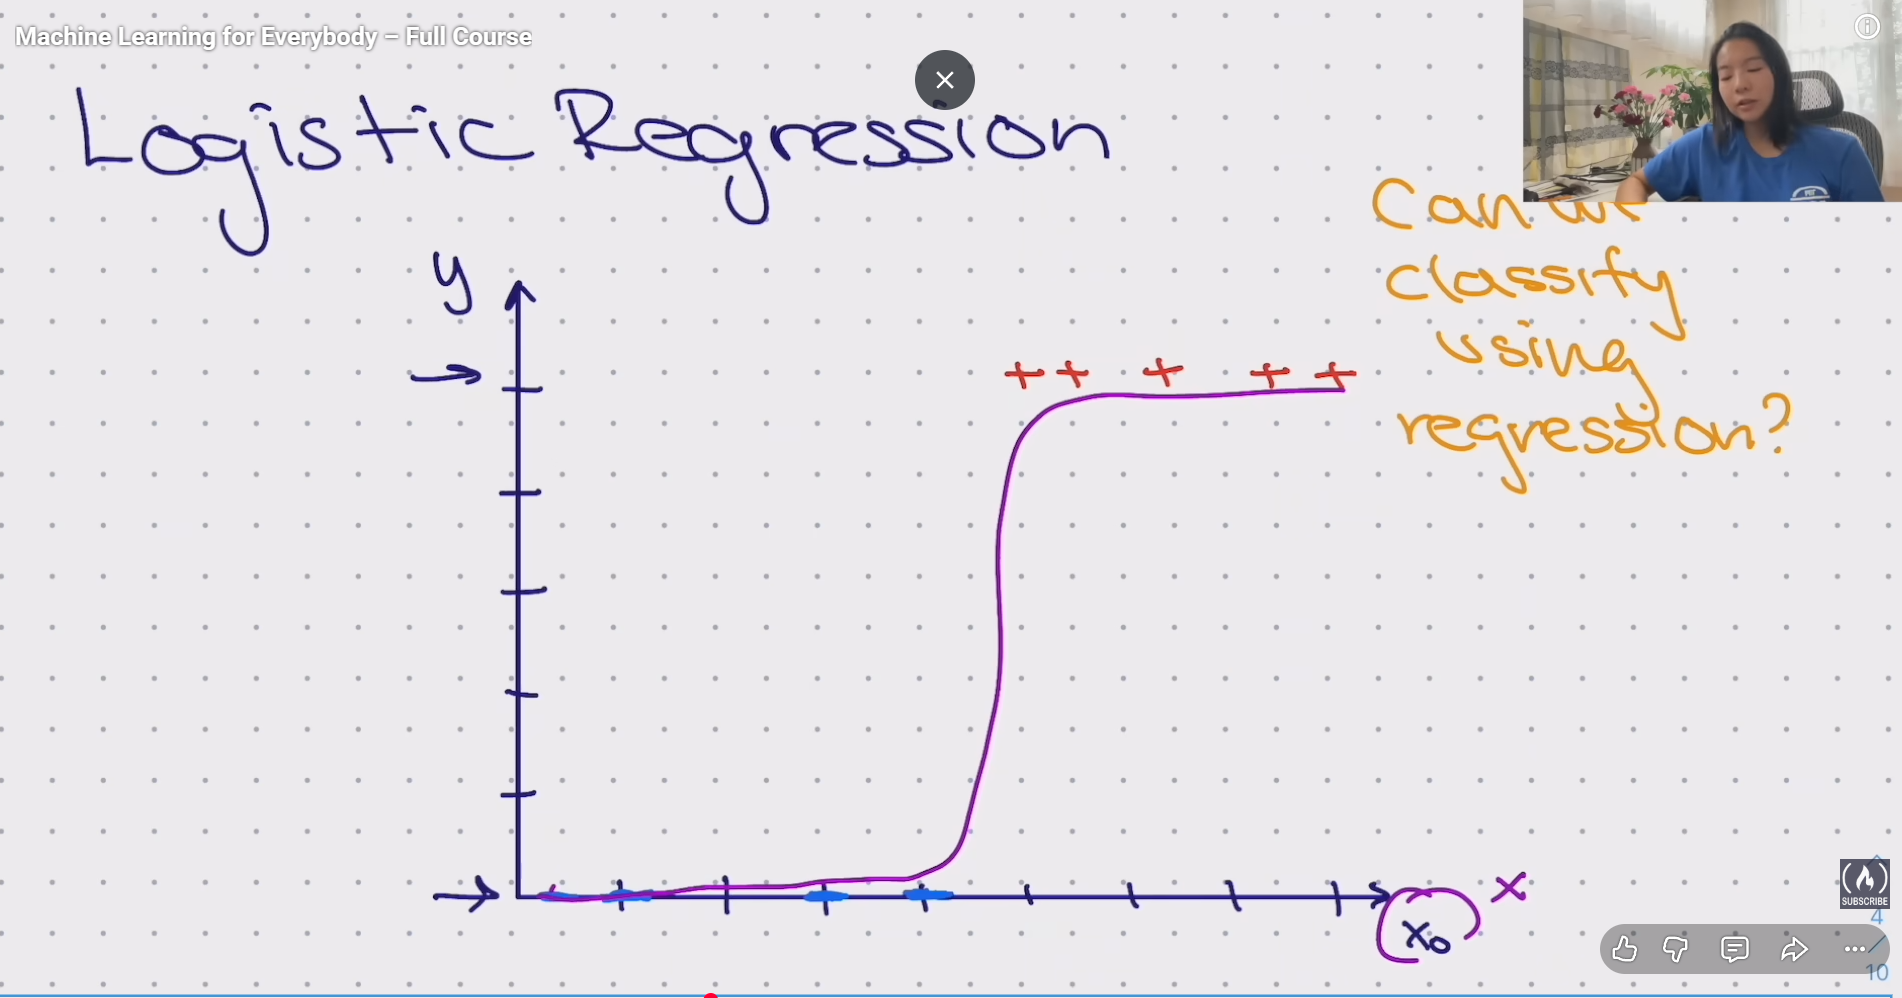

In [34]:
from sklearn.linear_model import LogisticRegression

In [36]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [38]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      1351
           1       0.84      0.83      0.83      2453

    accuracy                           0.79      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.79      0.79      3804



# Support Vector Machines (SVM)


Find the best boundary that separates different categories

SVM wants the boundary to be as far as possible from the closest examples on both sides

SVM can use something called a kernel to create a more complicated boundary

Kernel → helps SVM separate data that isn't linearly separable.

SVM

Training data
     ↓
Find the best boundary
     ↓
Maximize the margin
     ↓
Use support vectors
     ↓
Classify new data


In [39]:
from sklearn.svm import SVC

In [40]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [42]:
y_prep = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.72      0.70      1351
           1       0.84      0.83      0.83      2453

    accuracy                           0.79      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.79      0.79      3804



# Neural Network

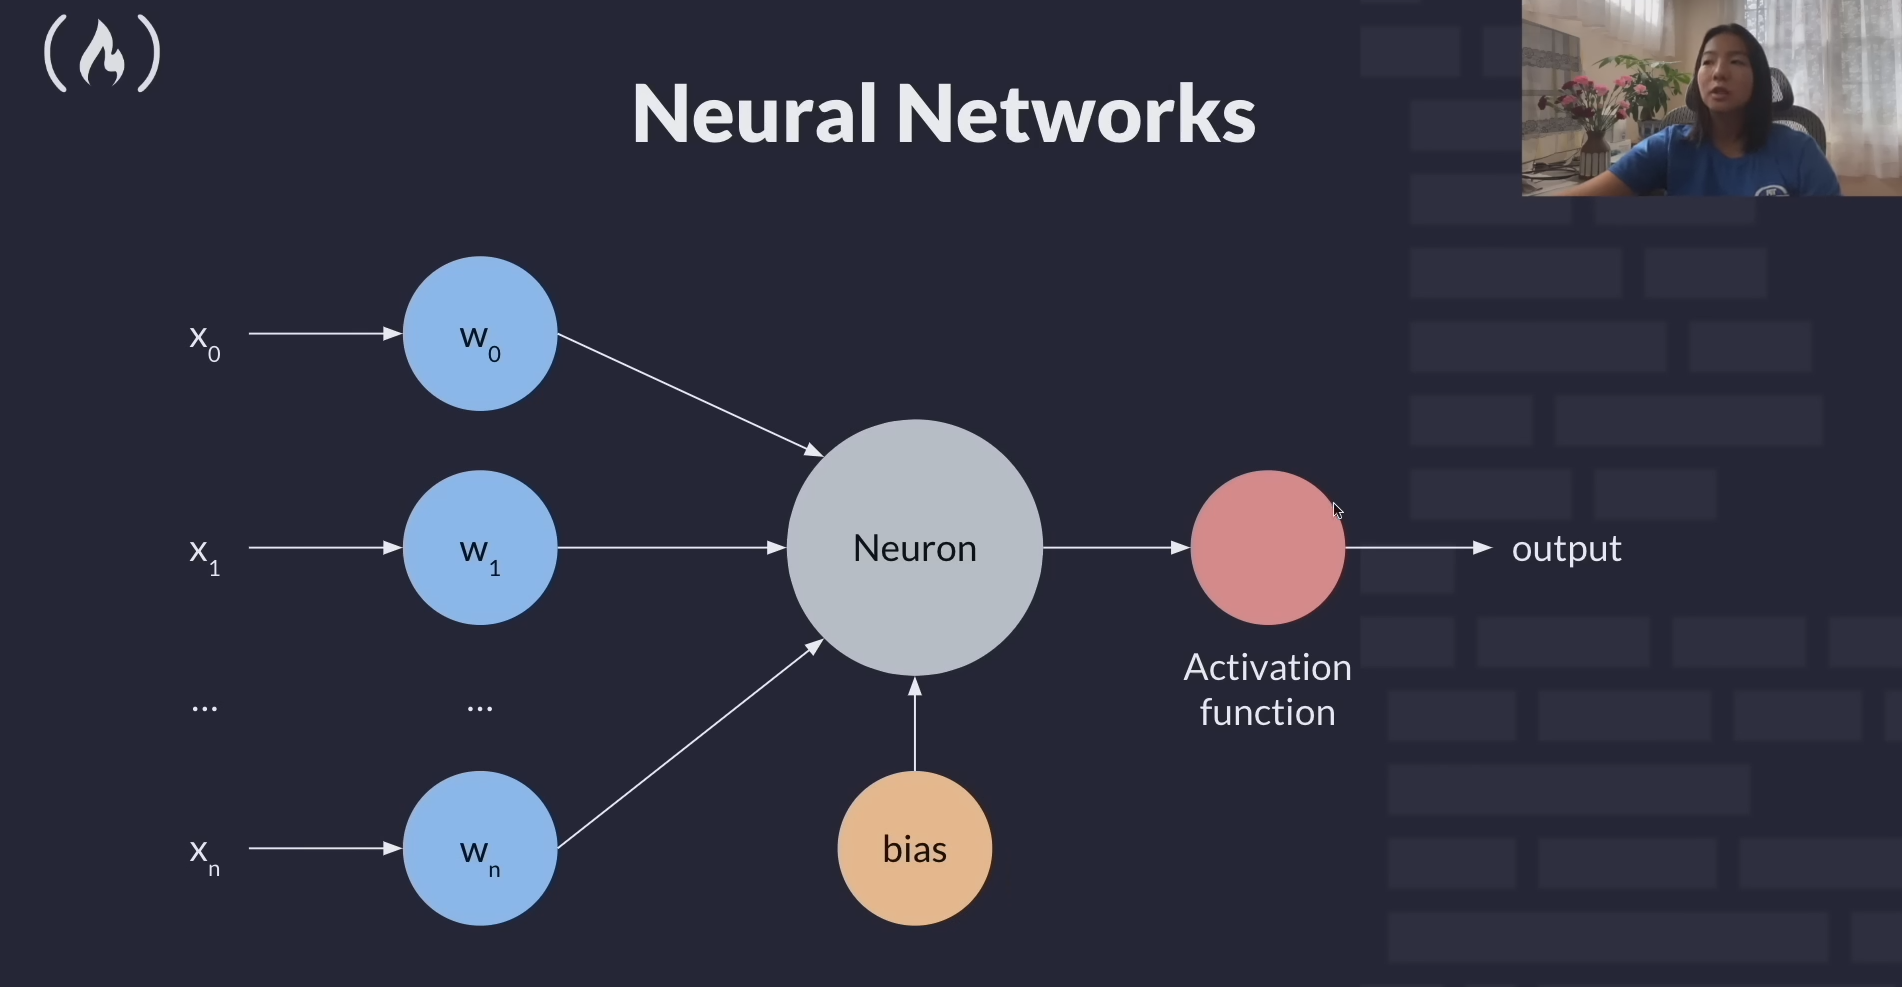

In [44]:
import tensorflow as tf

In [59]:
def plot_history(history):
  fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,4))
  ax1.plot(history.history['loss'], label='loss')
  ax1.plot(history.history['val_loss'], label='val_loss')
  ax1.set_xlabel('Epoch')
  ax1.set_ylabel('Binary crossentropy')
  ax1.legend()
  ax1.grid(True)

  ax2.plot(history.history['accuracy'], label='accuracy')
  ax2.plot(history.history['val_accuracy'], label='val_accuracy')
  ax2.set_xlabel('Epoch')
  ax2.set_ylabel('Accuracy')
  ax2.legend()
  ax2.grid(True)

  plt.show()

In [52]:
def train_model(X_train, y_train, num_nodes, dropout_prob, learn_rate, batch_size, epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape = (10,)),  # relu = anything < 0 is 0 and others linear regression
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')  #sigmoid = 0 or 1 with border line of 0.5
  ])

  nn_model.compile(optimizer=tf.keras.optimizers.Adam(learn_rate), loss='binary_crossentropy', metrics=['accuracy'])

  history = nn_model.fit(
      X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0
  )

  return nn_model, history


nodes 16, dropout 0, learn rate 0.01, batch size 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


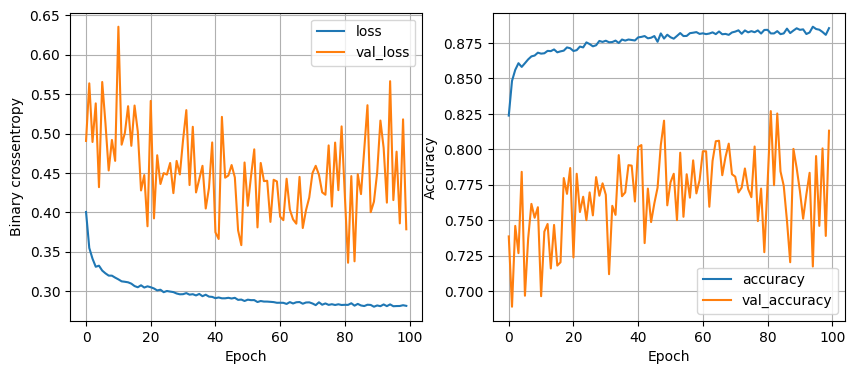

nodes 16, dropout 0, learn rate 0.01, batch size 64


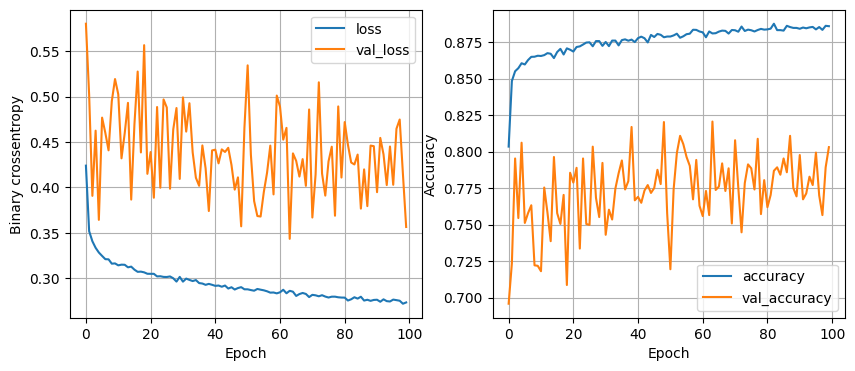

nodes 16, dropout 0, learn rate 0.01, batch size 128


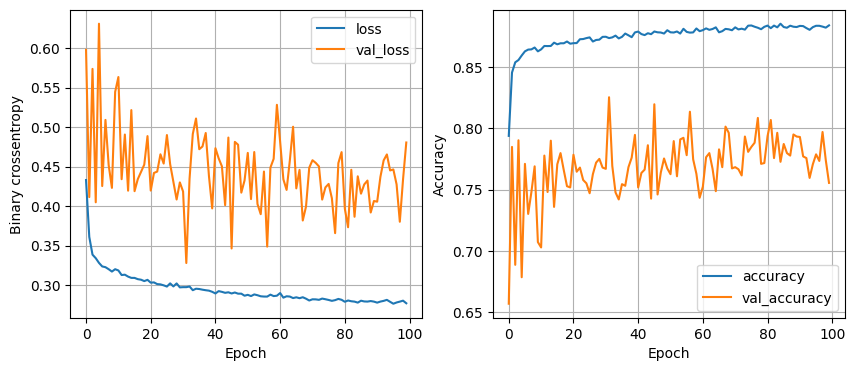

nodes 16, dropout 0, learn rate 0.005, batch size 32


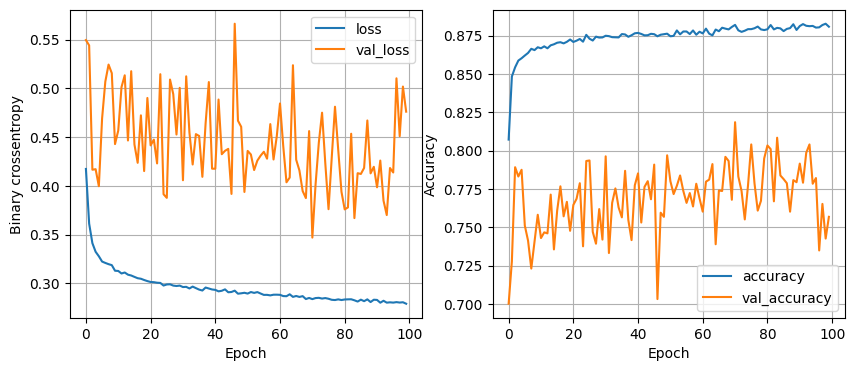

nodes 16, dropout 0, learn rate 0.005, batch size 64


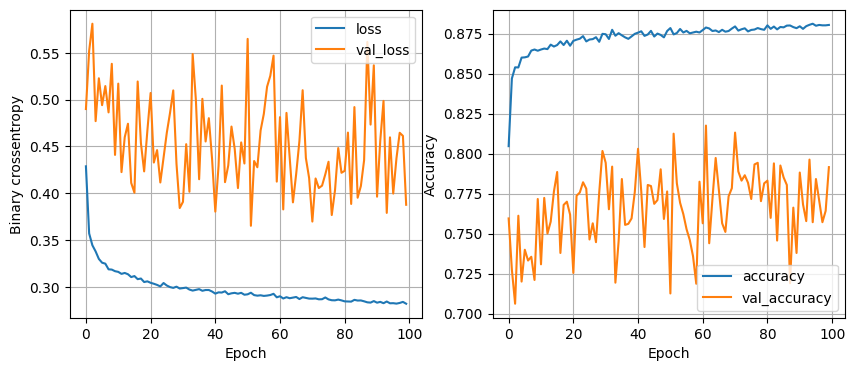

nodes 16, dropout 0, learn rate 0.005, batch size 128


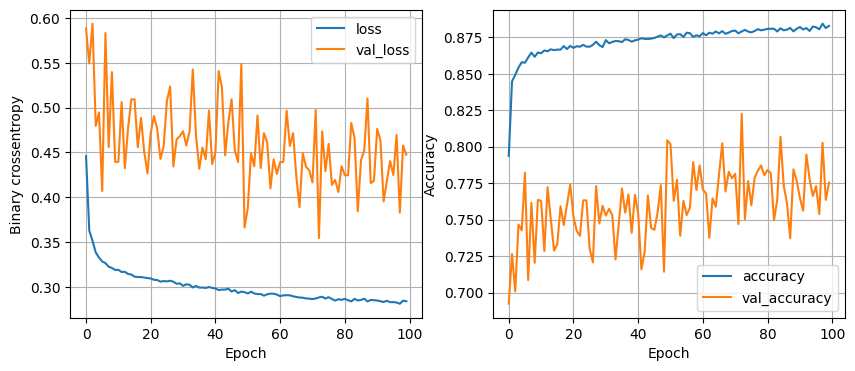

nodes 16, dropout 0, learn rate 0.001, batch size 32


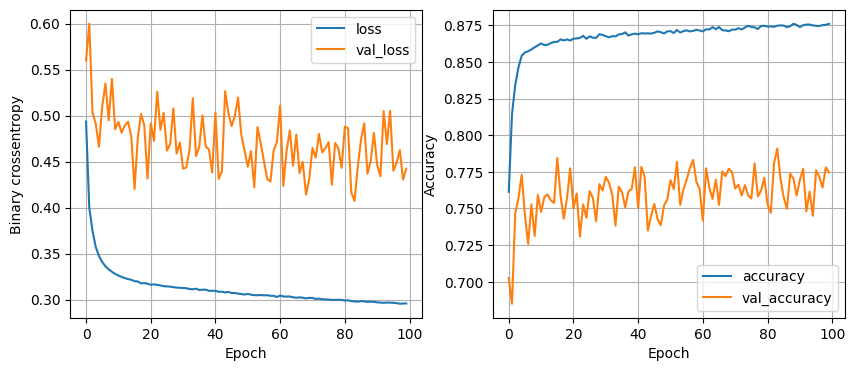

nodes 16, dropout 0, learn rate 0.001, batch size 64


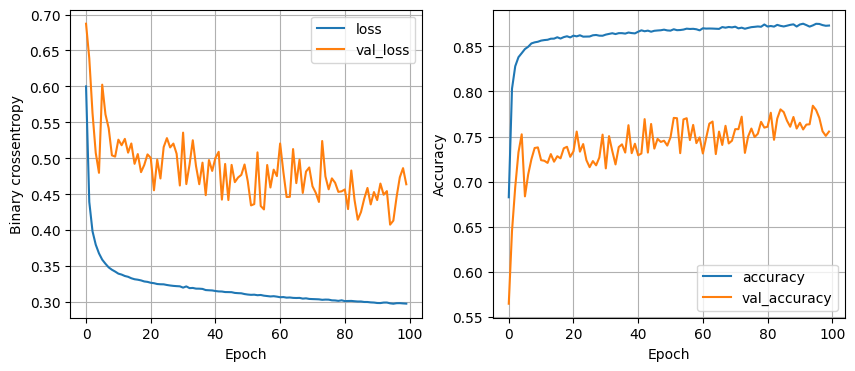

nodes 16, dropout 0, learn rate 0.001, batch size 128


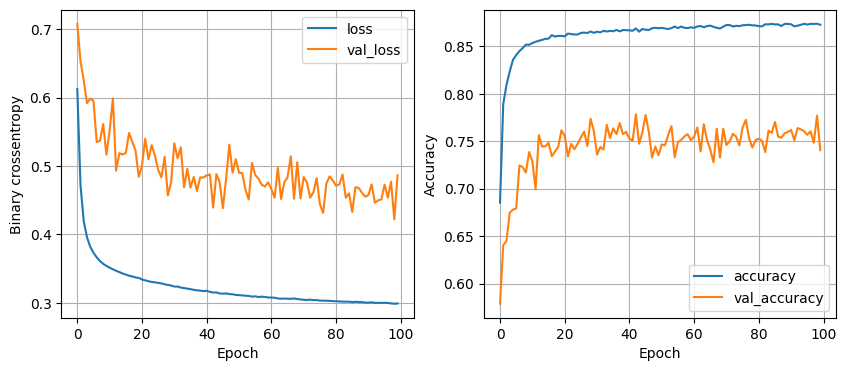

nodes 16, dropout 0.2, learn rate 0.01, batch size 32


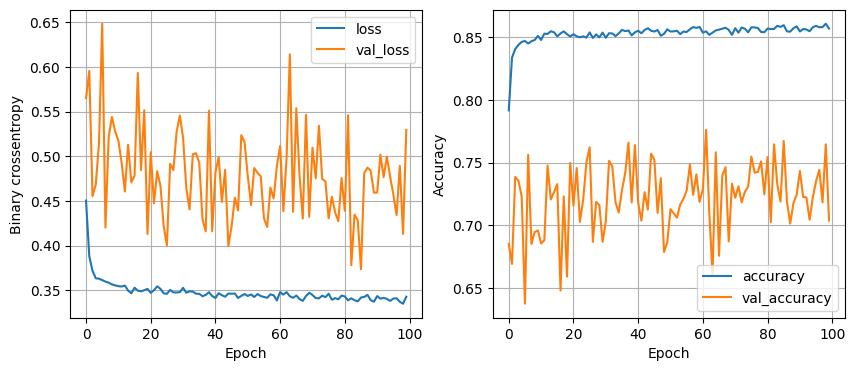

nodes 16, dropout 0.2, learn rate 0.01, batch size 64


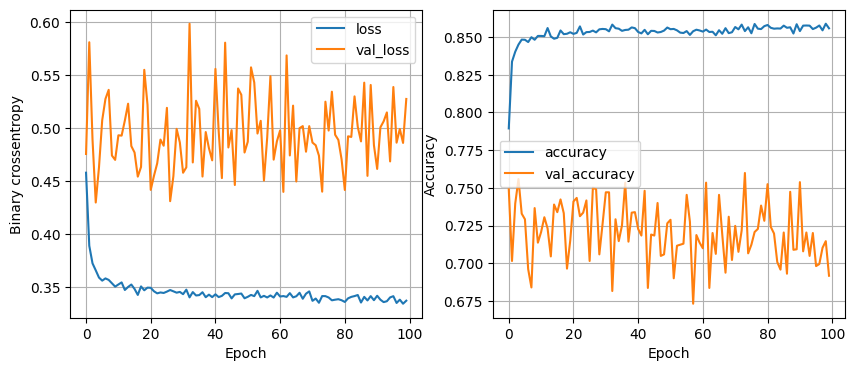

nodes 16, dropout 0.2, learn rate 0.01, batch size 128


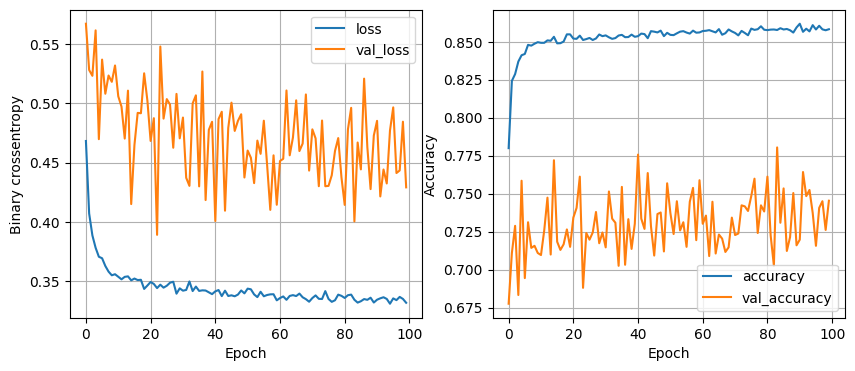

nodes 16, dropout 0.2, learn rate 0.005, batch size 32


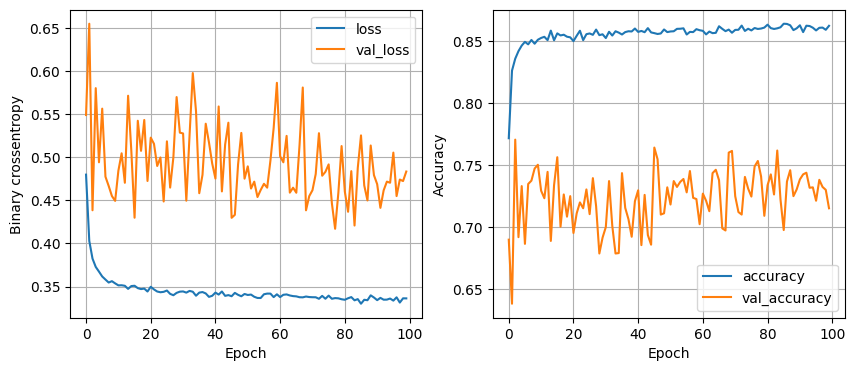

nodes 16, dropout 0.2, learn rate 0.005, batch size 64


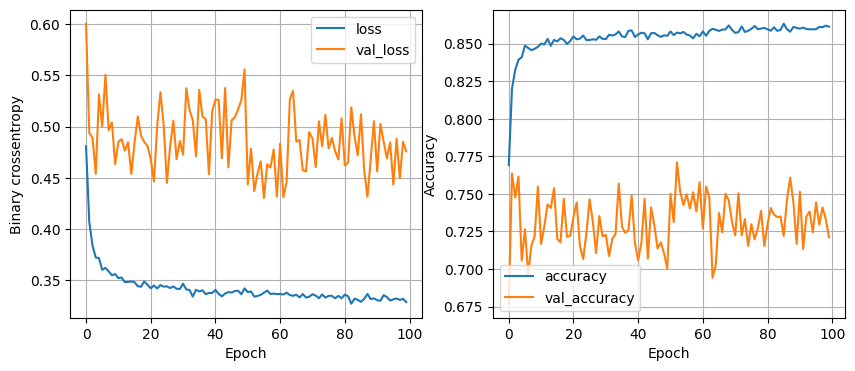

nodes 16, dropout 0.2, learn rate 0.005, batch size 128


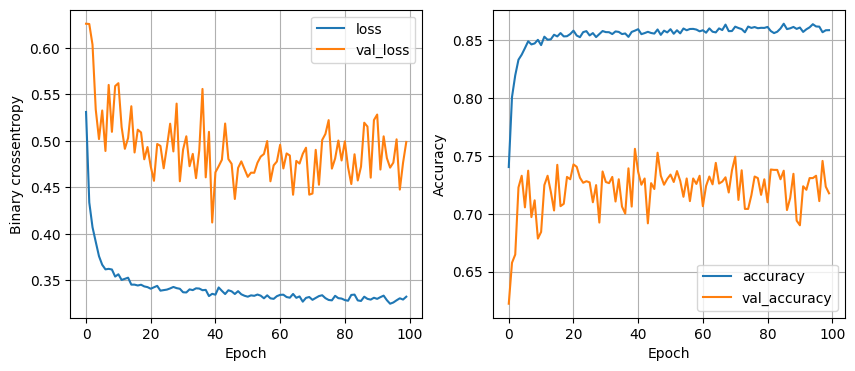

nodes 16, dropout 0.2, learn rate 0.001, batch size 32


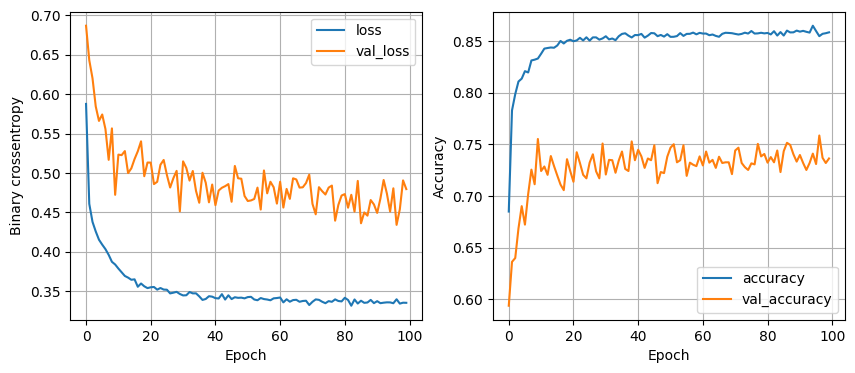

nodes 16, dropout 0.2, learn rate 0.001, batch size 64


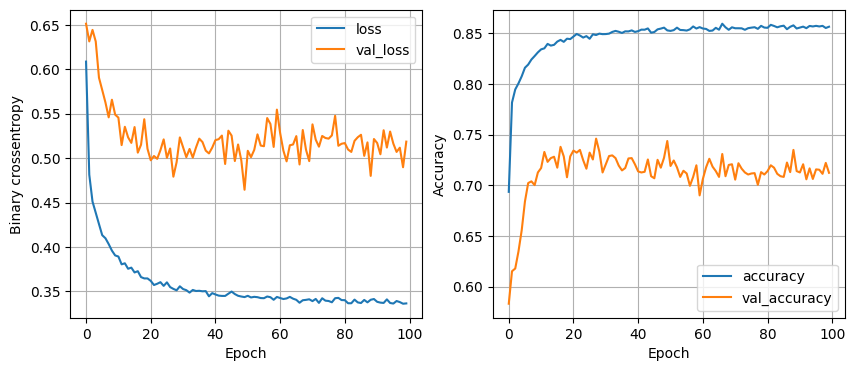

nodes 16, dropout 0.2, learn rate 0.001, batch size 128


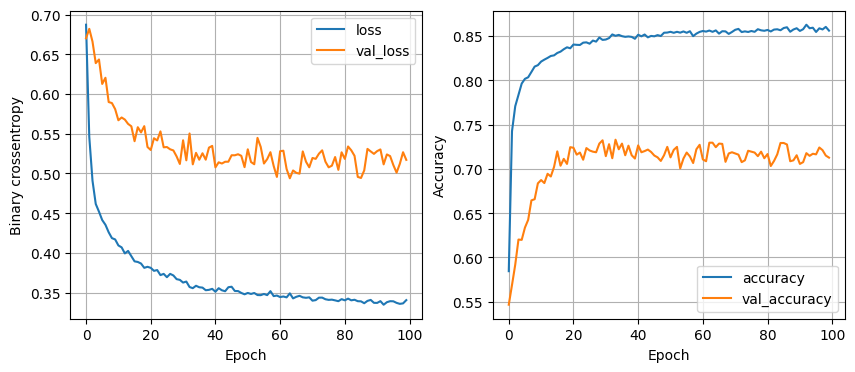

nodes 32, dropout 0, learn rate 0.01, batch size 32


KeyboardInterrupt: 

In [63]:
least_val_loss = float('inf')  #infinity
least_loss_model = None
epochs = 100
for num_nodes in [16, 32, 64]:
  for dropout_prob in [0, 0.2]:
    for learn_rate in [0.01, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"nodes {num_nodes}, dropout {dropout_prob}, learn rate {learn_rate}, batch size {batch_size}")
        model, history = train_model(X_train, y_train, num_nodes, dropout_prob, learn_rate, batch_size, epochs)
        plot_history(history)

        # model.evaluate returns a list: [loss, accuracy]
        # We need to take the loss value (the first element) for comparison.
        val_loss, _ = model.evaluate(X_valid, y_valid, verbose=0) # Set verbose to 0 to suppress output during loop
        if val_loss < least_val_loss:
          least_val_loss = val_loss
          least_loss_model = model